###  Imports and Load Dataset
I imported all the libraries I need for this project and loaded the wine dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
df = pd.read_csv("WineQT.csv")
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Statistic Tasks

In this section, I explore the WineQT dataset using a correlation heatmap, bar plots, and line plots to understand how different attributes behave.


Top 3 features most correlated with quality:
alcohol             0.484866
volatile acidity   -0.407394
sulphates           0.257710
Name: quality, dtype: float64


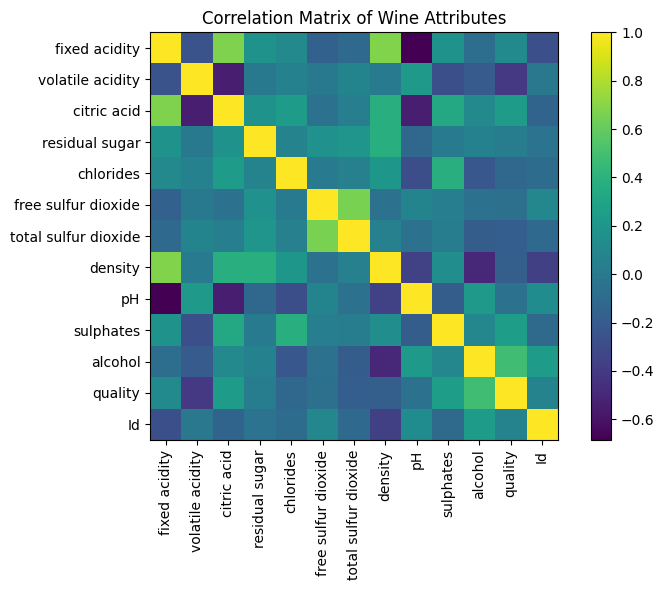

In [2]:
# --- Statistic Task 1: Correlation heatmap and top 3 features related to quality ---

# Compute correlation matrix for numeric columns
corr = df.corr(numeric_only=True)

# Sort correlations with quality (ignore quality vs quality)
quality_corr = corr['quality'].drop('quality').sort_values(key=lambda x: x.abs(), ascending=False)

top3_features = quality_corr.head(3)
print("Top 3 features most correlated with quality:")
print(top3_features)

# Plot full correlation heatmap
plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix of Wine Attributes")
plt.tight_layout()
plt.show()


### Statistic Task 1: Correlation Heatmap

I used a correlation matrix to see how each chemical attribute relates to wine quality. The three features with the strongest (absolute) correlation to quality are printed above. The heatmap helps compare how all numeric attributes relate to each other and to quality.


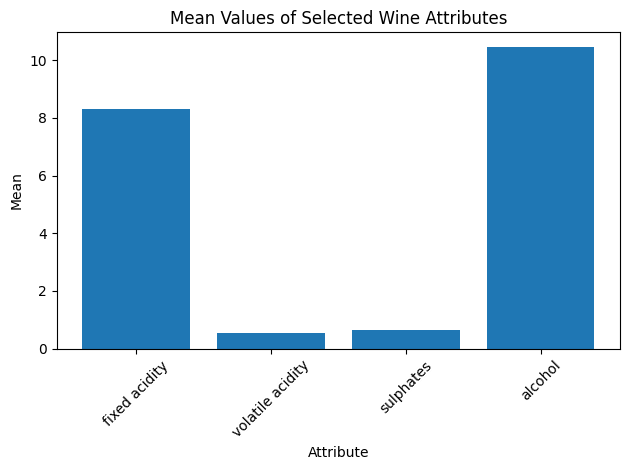

In [3]:
# --- Statistic Task 2: Bar plot for 4 attributes ---

# Choose any 4 attributes
bar_attrs = ['fixed acidity', 'volatile acidity', 'sulphates', 'alcohol']

# Use the mean of each attribute
means = df[bar_attrs].mean()

plt.figure()
plt.bar(bar_attrs, means)
plt.title("Mean Values of Selected Wine Attributes")
plt.xlabel("Attribute")
plt.ylabel("Mean")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Statistic Task 2: Bar Plot

Here I plotted the mean values of four attributes: fixed acidity, volatile acidity, sulphates, and alcohol. This gives a quick overview of the typical levels of each attribute in the dataset and shows that alcohol is on a different scale than the acid-related features.


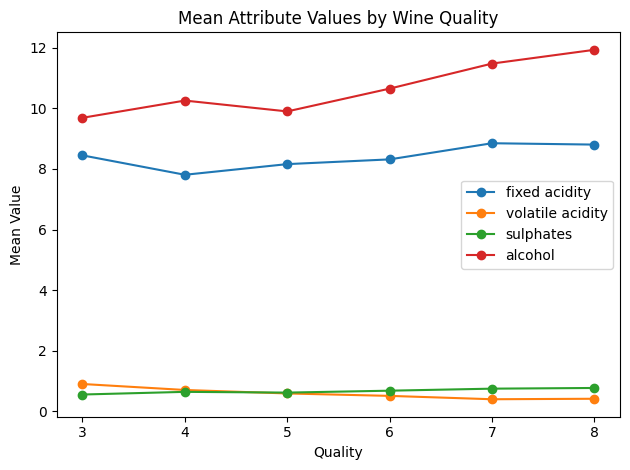

In [4]:
# --- Statistic Task 3: Line plot for 4 attributes vs quality ---

line_attrs = ['fixed acidity', 'volatile acidity', 'sulphates', 'alcohol']

# Group by quality and compute mean for each selected attribute
grouped = df.groupby('quality')[line_attrs].mean()

plt.figure()
for col in line_attrs:
    plt.plot(grouped.index, grouped[col], marker='o', label=col)

plt.title("Mean Attribute Values by Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Mean Value")
plt.legend()
plt.tight_layout()
plt.show()


### Statistic Task 3: Line Plot

I plotted the mean values of four attributes by wine quality score. This shows how these attributes change as quality increases. For example, in many wine datasets, alcohol and sulphates tend to be higher in better-rated wines, while volatile acidity is often lower for higher quality.


## Data Mining Tasks

Next, I apply two data mining techniques to the WineQT dataset:
* K-Means clustering to group wines into price-like categories.
* K-NN to predict wine quality and find the best number of neighbors.


In [5]:
# --- K-Means: Prepare features and scale ---

# Select 7 chemical attributes for K-Means
kmeans_features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'chlorides',
    'free sulfur dioxide',
    'sulphates',
    'alcohol'
]

X_kmeans = df[kmeans_features].values

# Scale features
kmeans_scaler = StandardScaler()
X_kmeans_scaled = kmeans_scaler.fit_transform(X_kmeans)

X_kmeans_scaled[:5]



array([[-0.52157961,  0.93933222, -1.36502663, -0.23139486, -0.45046702,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663,  0.23424656,  0.91591972,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762,  0.10725344, -0.06007081,
        -0.04525363, -0.59360107],
       [ 1.65378902, -1.39978919,  1.48339955, -0.25256038,  0.1351273 ,
        -0.45623467, -0.59360107],
       [-0.52157961,  0.93933222, -1.36502663, -0.23139486, -0.45046702,
        -0.57365783, -0.96338181]])

In [6]:
# --- K-Means: Find best K using silhouette score ---

K_values = range(2, 11)
sil_scores = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(X_kmeans_scaled)
    sil_scores.append(silhouette_score(X_kmeans_scaled, labels))

sil_scores



[0.2693627002983004,
 0.27530112813013163,
 0.2297611824912092,
 0.2131740736884278,
 0.2105080314857892,
 0.16572767015860698,
 0.16127417931937602,
 0.17641257611077352,
 0.18164926054033956]

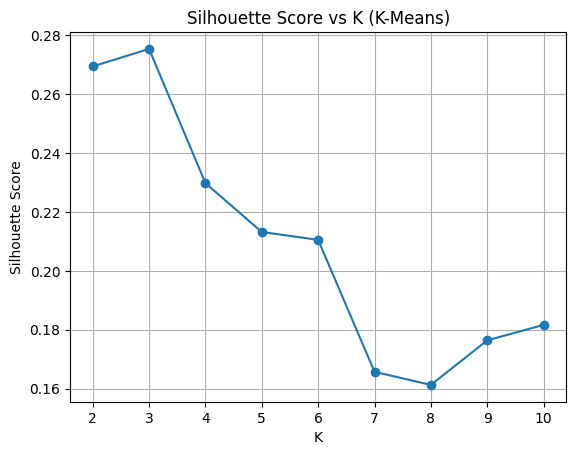

In [7]:
plt.figure()
plt.plot(K_values, sil_scores, marker='o')
plt.title("Silhouette Score vs K (K-Means)")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.xticks(K_values)
plt.grid(True)
plt.show()


In [8]:
# --- K-Means: Train final model with best K ---

best_k = K_values[int(np.argmax(sil_scores))]
print("Best K from silhouette score:", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=0, n_init='auto')
kmeans_labels = kmeans_final.fit_predict(X_kmeans_scaled)

# Save cluster labels
df['cluster'] = kmeans_labels

# Get centroids
kmeans_centroids = kmeans_final.cluster_centers_

# Define simple "price" labels based on quality (low, medium, high)
def quality_to_price(q):
    if q <= 5:
        return "low"
    elif q == 6:
        return "medium"
    else:
        return "high"

df['price_label'] = df['quality'].apply(quality_to_price)

# Compare clusters and price labels
pd.crosstab(df['cluster'], df['price_label'])



Best K from silhouette score: 3


price_label,high,low,medium
cluster,,,
0,1,11,7
1,121,115,182
2,37,396,273


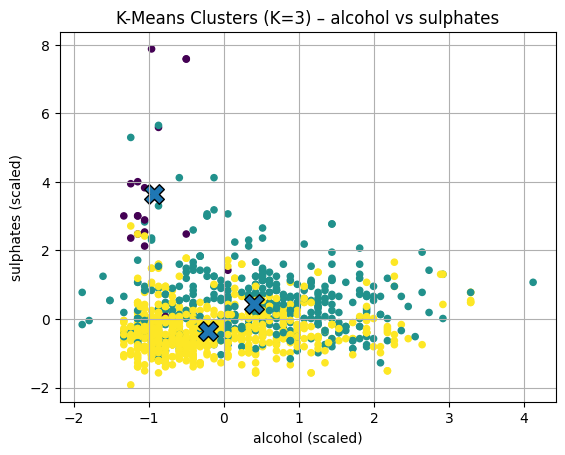

In [9]:
# --- K-Means: 2D cluster visualization (alcohol vs sulphates) ---

x_attr = 'alcohol'
y_attr = 'sulphates'

x_idx = kmeans_features.index(x_attr)
y_idx = kmeans_features.index(y_attr)

X_plot_x = X_kmeans_scaled[:, x_idx]
X_plot_y = X_kmeans_scaled[:, y_idx]

centroids_x = kmeans_centroids[:, x_idx]
centroids_y = kmeans_centroids[:, y_idx]

plt.figure()
plt.scatter(X_plot_x, X_plot_y, c=kmeans_labels, s=20)
plt.scatter(centroids_x, centroids_y, marker='X', s=200, edgecolor='black')
plt.xlabel(f"{x_attr} (scaled)")
plt.ylabel(f"{y_attr} (scaled)")
plt.title(f"K-Means Clusters (K={best_k}) – {x_attr} vs {y_attr}")
plt.grid(True)
plt.show()


### K-Means Results

I used seven chemical features to cluster the wines with K-Means. I chose the best number of clusters (K) using the silhouette score. Then I defined simple "price" labels based on wine quality (low, medium, high) and compared them to the clusters with a crosstab. The scatter plot (alcohol vs sulphates) shows how the clusters separate in 2D, with centroids marked by X.


In [10]:
# --- K-NN: Prepare features and target ---

# Use all main chemical attributes as features for K-NN
knn_features = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol'
]

X_knn = df[knn_features].values
y_knn = df['quality'].values  # target is quality score

# Scale features for K-NN
knn_scaler = StandardScaler()
X_knn_scaled = knn_scaler.fit_transform(X_knn)

X_knn_scaled[:5], y_knn[:5]


(array([[-0.52157961,  0.93933222, -1.36502663, -0.46642142, -0.23139486,
         -0.45046702, -0.3636101 ,  0.55585438,  1.27069495, -0.57365783,
         -0.96338181],
        [-0.29259344,  1.94181282, -1.36502663,  0.05006018,  0.23424656,
          0.91591972,  0.64347653,  0.03616459, -0.70892755,  0.1308811 ,
         -0.59360107],
        [-0.29259344,  1.27349242, -1.16156762, -0.17128908,  0.10725344,
         -0.06007081,  0.24674544,  0.14010255, -0.32577481, -0.04525363,
         -0.59360107],
        [ 1.65378902, -1.39978919,  1.48339955, -0.46642142, -0.25256038,
          0.1351273 ,  0.4298521 ,  0.65979234, -0.96436271, -0.45623467,
         -0.59360107],
        [-0.52157961,  0.93933222, -1.36502663, -0.46642142, -0.23139486,
         -0.45046702, -0.3636101 ,  0.55585438,  1.27069495, -0.57365783,
         -0.96338181]]),
 array([5, 5, 5, 6, 5]))

In [11]:
# --- K-NN: Cross-validation to find optimal k ---

k_values = range(1, 26)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_knn_scaled, y_knn, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

cv_scores


[np.float64(0.4969240787558416),
 np.float64(0.4978127633494216),
 np.float64(0.4846663602237034),
 np.float64(0.5152876733318011),
 np.float64(0.5415268520646594),
 np.float64(0.5389450700988279),
 np.float64(0.5511453305753466),
 np.float64(0.5336627595188845),
 np.float64(0.5406419980081207),
 np.float64(0.5372174978932047),
 np.float64(0.5275760361602696),
 np.float64(0.5337010648892975),
 np.float64(0.5406688117674097),
 np.float64(0.5407109476748639),
 np.float64(0.5415766490461962),
 np.float64(0.5520684900022983),
 np.float64(0.5511683137975945),
 np.float64(0.5415843101202789),
 np.float64(0.545062437753773),
 np.float64(0.5476825250900176),
 np.float64(0.5468053321075615),
 np.float64(0.552064659465257),
 np.float64(0.5485673791465564),
 np.float64(0.5503102735003448),
 np.float64(0.5529341913736306)]

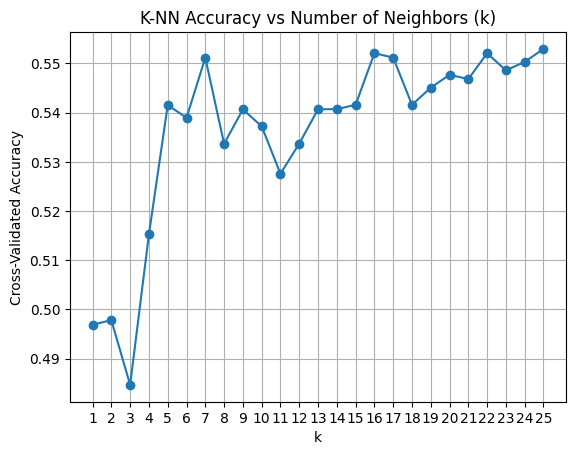

Best k for K-NN: 25
Best accuracy: 0.5529341913736306


In [12]:
plt.figure()
plt.plot(k_values, cv_scores, marker='o')
plt.title("K-NN Accuracy vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

best_k_knn = k_values[int(np.argmax(cv_scores))]
print("Best k for K-NN:", best_k_knn)
print("Best accuracy:", max(cv_scores))


### K-NN Results

For the K-NN model, I used the main chemical attributes as features and the wine quality score as the target. I tested k values from 1 to 25 using 5-fold cross-validation. The plot shows how accuracy changes with k. The k value with the highest accuracy is chosen as the optimal number of neighbors for predicting wine quality.
